# PSPO safe policy update in 3D: propose, expand, project

Pick a PSPO type in the configuration cell and the notebook draws the three
stages of one enforcement step in a 3D parameter space
$\theta=(\theta_1,\theta_2,\theta_3)$. In every type, PPO first proposes an
unconstrained step $\Delta_k$ from the last certified parameters $\theta_k$ to
$\bar\theta_{k+1}=\theta_k+\Delta_k$, which here leaves the safe set
$\Theta^{\mathrm{safe}}$. The types differ in what happens next, and each one
matches a training configuration of `stages/train_pspo.py`:

| `PSPO_TYPE` | configuration | (b) | (c) |
|---|---|---|---|
| `"default"` | `verify_first=False`, `safe_region_shape="orthotope"` | grow the directional orthotope LID (`pspo_main.tex`, Eq. directional-lid-program-main) | $\ell_2$ projection onto the box, a coordinate-wise clip |
| `"verify-first"` | `verify_first=True` (`AdaptiveSafePPO`) | check the proposal itself exactly; a LID is built only if the check fails | fall back: grow the same orthotope LID and project onto it |
| `"line-segment"` | `safe_region_shape="segment"` | certify the longest prefix $\theta_k+[0,\hat\alpha]\Delta_k$ with $K=4$ sub-segments (`pspo_segment_lid.tex`) | the projection is the shortened step $\theta_k+\hat\alpha\Delta_k$ |

All three grow towards $\Delta_k$ (directional growth, weighted-width
objective $\sum_j w_{k,j} g_j$ with $w_{k,j}=|\Delta_{k,j}|/\|\Delta_k\|_1$), as
recorded in `docs/pspo_best_settings.yaml`.

The geometry is computed, not hand-placed: each LID really is the maximiser of
its program, and every drawn certified set is checked to lie inside
$\Theta^{\mathrm{safe}}$. A dense membership test stands in for the hard IBP
certificate; it is exact here, whereas IBP is conservative, so real LIDs sit
further inside the safe set.

In [2]:
from __future__ import annotations

import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch, Patch
from mpl_toolkits.mplot3d import proj3d
from mpl_toolkits.mplot3d.art3d import Line3DCollection, Poly3DCollection


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "projects/safe_policy_optimisation/scripts/_paper_style.py").is_file():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the CertifiedContinualLearning repo.")


REPO = find_repo_root(Path.cwd().resolve())
sys.path.insert(0, str(REPO / "projects/safe_policy_optimisation/scripts"))

from _paper_style import (  # noqa: E402
    INK_PRIMARY,
    INK_SECONDARY,
    METHOD_COLORS,
    SURFACE,
    TEXT_WIDTH_IN,
    apply_paper_style,
    save_paper_figure,
)

FIGURE_DIR = REPO / "projects/safe_policy_optimisation/figures"

apply_paper_style()

## Configuration

`PSPO_TYPE` selects the figure. `build_figure(pspo_type)` draws any of the
three types without editing this cell.

In [3]:
PSPO_TYPE = "default"  # "default", "verify-first" or "line-segment"
PSPO_TYPES = ("default", "verify-first", "line-segment")
assert PSPO_TYPE in PSPO_TYPES, f"PSPO_TYPE must be one of {PSPO_TYPES}, got {PSPO_TYPE!r}."

THETA_K = np.zeros(3)  # last certified parameters
DELTA_K = np.array([1.0, 0.32, 0.60])  # PPO step
THETA_BAR = THETA_K + DELTA_K  # uncertified proposal
B_MAX = 1.2  # per-coordinate growth cap b_max
N_SEGMENT_PARTS = 4  # K sub-segments in the segment certificate (segment_splits; drawn as ticks)

# Safe set: a smooth, non-convex, tilted blob, star-shaped about its centre.
# SAFE_CUBE squares it off (so the box can grow past the proposal in theta_2),
# SAFE_LOBE breaks its symmetry.
SAFE_CENTRE = np.array([0.24, 0.30, 0.20])
SAFE_RADIUS = 0.52
SAFE_CUBE = 0.40
SAFE_LOBE = 0.06
SAFE_SCALE = np.array([1.0, 1.15, 0.9])
SAFE_TILT_DEG = (-12.0, 10.0, 0.0)  # yaw, pitch, roll

# Colours. Green is PSPO's colour in every paper figure; the raspberry
# proposal colour passes the CVD check against it (protan/deutan dE 8.7),
# which a pure red does not.
LID = METHOD_COLORS["pspo"]
PROPOSAL = "#b8336a"
SAFE_TONE = "#a3a29a"
SAFE_FILL = "#ebeae4"

LIMITS = np.array([(-0.40, 1.08), (-0.40, 1.00), (-0.34, 0.78)])
VIEW = {"elev": 20.0, "azim": -62.0}
ZOOM = 1.45
TRIAD_ORIGIN = np.array([-0.10, -0.40, -0.36])  # where the small theta_1/2/3 axes sit; move it with VIEW


def out_stem(pspo_type: str) -> Path:
    return FIGURE_DIR / f"pspo_safe_update_{pspo_type.replace('-', '_')}_3d"

## Geometry

`certified` is the stand-in certificate: a set of sampled parameters is
accepted iff every sample lies in $\Theta^{\mathrm{safe}}$.

The orthotope program is solved on a $121^3$ grid of widths. A box anchored at
$\theta_k$ is certified iff no unsafe grid point lies inside it, which a 3D
cumulative sum of the unsafe indicator decides for every candidate box at
once. The winning box is then re-checked on a dense sample of its surface;
that suffices because the safe set is star-shaped, so its complement is
connected and cannot reach the inside of a box whose surface is safe.

In [4]:
def rotation(yaw: float, pitch: float, roll: float) -> np.ndarray:
    a, b, c = np.deg2rad([yaw, pitch, roll])
    rz = np.array([[np.cos(a), -np.sin(a), 0.0], [np.sin(a), np.cos(a), 0.0], [0.0, 0.0, 1.0]])
    ry = np.array([[np.cos(b), 0.0, np.sin(b)], [0.0, 1.0, 0.0], [-np.sin(b), 0.0, np.cos(b)]])
    rx = np.array([[1.0, 0.0, 0.0], [0.0, np.cos(c), -np.sin(c)], [0.0, np.sin(c), np.cos(c)]])
    return rz @ ry @ rx


_ROT = rotation(*SAFE_TILT_DEG)


def safe_radius(direction: np.ndarray) -> np.ndarray:
    """Boundary radius along unit ``direction`` in the blob's local frame."""
    cube = (direction**4).sum(axis=-1) - 0.6
    lobe = direction[..., 0] ** 3 - 3.0 * direction[..., 0] * direction[..., 1] ** 2
    return SAFE_RADIUS * (1.0 - SAFE_CUBE * cube + SAFE_LOBE * lobe)


def in_safe_set(points: np.ndarray) -> np.ndarray:
    local = ((points - SAFE_CENTRE) @ _ROT) / SAFE_SCALE
    norm = np.linalg.norm(local, axis=-1)
    return norm < safe_radius(local / np.maximum(norm, 1e-12)[..., None])


def safe_surface(n_u: int = 73, n_v: int = 37) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    u, v = np.meshgrid(np.linspace(0.0, 2.0 * np.pi, n_u), np.linspace(0.0, np.pi, n_v))
    direction = np.stack([np.sin(v) * np.cos(u), np.sin(v) * np.sin(u), np.cos(v)], axis=-1)
    points = SAFE_CENTRE + (safe_radius(direction)[..., None] * direction * SAFE_SCALE) @ _ROT.T
    return points[..., 0], points[..., 1], points[..., 2]


def certified(points: np.ndarray) -> np.ndarray:
    """Hard-certificate stand-in: all sampled parameters are safe."""
    return in_safe_set(points).all(axis=-1)


def _unit_cube_surface(n: int = 21) -> np.ndarray:
    a, b = (x.ravel() for x in np.meshgrid(*(np.linspace(0.0, 1.0, n),) * 2))
    faces = []
    for axis in range(3):
        p, q = (i for i in range(3) if i != axis)
        for side in (0.0, 1.0):
            face = np.empty((a.size, 3))
            face[:, axis], face[:, p], face[:, q] = side, a, b
            faces.append(face)
    return np.concatenate(faces)


_UNIT_SURFACE = _unit_cube_surface()


def directional_box(widths: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """[l(g), u(g)]: coordinate j grows by g_j only on the side of sign(Delta_kj)."""
    lower = THETA_K - (DELTA_K < 0) * widths
    upper = THETA_K + (DELTA_K > 0) * widths
    return lower, upper


def box_certified(widths: np.ndarray) -> bool:
    lower, upper = directional_box(widths)
    return bool(certified(lower + (upper - lower) * _UNIT_SURFACE))


def fit_orthotope_lid(n_grid: int = 121) -> tuple[np.ndarray, np.ndarray]:
    """max_g sum_j w_j g_j s.t. the directional box is certified, 0 <= g <= b_max."""
    weights = np.abs(DELTA_K) / np.abs(DELTA_K).sum()
    side = np.sign(DELTA_K)  # coordinates with Delta_kj = 0 stay frozen
    grid = np.linspace(0.0, B_MAX, n_grid)
    widths = np.stack(np.meshgrid(grid, grid, grid, indexing="ij"), axis=-1) * np.abs(side)
    unsafe = ~in_safe_set(THETA_K + side * widths)
    blocked = unsafe.cumsum(axis=0).cumsum(axis=1).cumsum(axis=2) > 0
    candidates = widths[~blocked]
    for index in np.argsort(-(candidates @ weights)):
        if box_certified(candidates[index]):
            return directional_box(candidates[index])
    raise RuntimeError("No certified box: theta_k itself is outside the safe set.")


def fit_segment_lid(n_samples: int = 2001, n_bisect: int = 40) -> float:
    """max alpha in [0, 1] s.t. {theta_k + t Delta_k : t in [0, alpha]} is certified."""
    t = np.linspace(0.0, 1.0, n_samples)[:, None]
    if certified(THETA_K + t * DELTA_K):
        return 1.0
    lo, hi = 0.0, 1.0
    for _ in range(n_bisect):
        mid = 0.5 * (lo + hi)
        lo, hi = (mid, hi) if certified(THETA_K + mid * t * DELTA_K) else (lo, mid)
    return lo

In [5]:
LID_LOWER, LID_UPPER = fit_orthotope_lid()
THETA_NEXT_BOX = np.clip(THETA_BAR, LID_LOWER, LID_UPPER)  # l2 projection onto a box
CLIPPED = ~np.isclose(THETA_NEXT_BOX, THETA_BAR)
CLIPPED_TEX = ",".join(rf"\theta_{j + 1}" for j in np.flatnonzero(CLIPPED))
KEPT_TEX = ",".join(rf"\theta_{j + 1}" for j in np.flatnonzero(~CLIPPED))

ALPHA_HAT = fit_segment_lid()
THETA_NEXT_SEGMENT = THETA_K + ALPHA_HAT * DELTA_K  # l2 projection onto the segment


def nearest(points: np.ndarray, target: np.ndarray) -> np.ndarray:
    return points[np.argmin(np.linalg.norm(points - target, axis=1))]


assert in_safe_set(THETA_K) and not in_safe_set(THETA_BAR)
assert not certified(THETA_K + _UNIT_SURFACE * DELTA_K), "a box containing the proposal must fail"
_grid = np.stack(np.meshgrid(*(np.linspace(0.0, 1.0, 41),) * 3, indexing="ij"), axis=-1).reshape(-1, 3)
assert np.allclose(nearest(LID_LOWER + (LID_UPPER - LID_LOWER) * _grid, THETA_BAR), THETA_NEXT_BOX, atol=0.02)
segment_points = THETA_K + np.linspace(0.0, ALPHA_HAT, 2001)[:, None] * DELTA_K
assert np.allclose(nearest(segment_points, THETA_BAR), THETA_NEXT_SEGMENT, atol=1e-3)

print(f"orthotope LID: l = {LID_LOWER.round(3)}, u = {LID_UPPER.round(3)}")
print(f"  theta_k+1 = {THETA_NEXT_BOX.round(3)}  (clipped coords: {np.flatnonzero(CLIPPED) + 1})")
print(f"segment LID: alpha_hat = {ALPHA_HAT:.3f}, theta_k+1 = {THETA_NEXT_SEGMENT.round(3)}")

orthotope LID: l = [0. 0. 0.], u = [0.62 0.65 0.45]
  theta_k+1 = [0.62 0.32 0.45]  (clipped coords: [1 3])
segment LID: alpha_hat = 0.713, theta_k+1 = [0.713 0.228 0.428]


## Drawing

Depth sorting is switched off (`computed_zorder = False`) and every artist gets
an explicit `zorder`, so the translucent safe set never hides the LID.

In [19]:
LABEL_SIZE = 6.5
SAFE_SURFACE = safe_surface()


class Arrow3D(FancyArrowPatch):
    """A 2D arrow patch re-projected from 3D endpoints on every draw."""

    def __init__(self, start, end, **kwargs):
        super().__init__((0.0, 0.0), (0.0, 0.0), **kwargs)
        self._segment = np.stack([start, end], axis=1)

    def do_3d_projection(self, renderer=None):
        xs, ys, zs = proj3d.proj_transform(*self._segment, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return float(np.min(zs))


def arrow(ax, start, end, *, color, lw=1.1, alpha=1.0, zorder=6):
    ax.add_artist(
        Arrow3D(start, end, arrowstyle="-|>", mutation_scale=6.5, lw=lw, color=color, alpha=alpha,
                shrinkA=0.0, shrinkB=1.5, zorder=zorder)
    )


def label(ax, point, text, *, color=INK_PRIMARY, shift=(0.0, 0.0, 0.0), ha="left", va="center"):
    ax.text(*(np.asarray(point) + shift), text, fontsize=LABEL_SIZE, color=color, ha=ha, va=va, zorder=10)


def line(ax, start, end, **kwargs):
    ax.plot(*np.stack([start, end], axis=1), **kwargs)


def box_faces(lower, upper):
    faces = []
    for axis in range(3):
        p, q = (i for i in range(3) if i != axis)
        for side in (lower[axis], upper[axis]):
            face = []
            for a, b in ((0, 0), (0, 1), (1, 1), (1, 0)):
                vertex = np.empty(3)
                vertex[axis], vertex[p], vertex[q] = side, (lower[p], upper[p])[a], (lower[q], upper[q])[b]
                face.append(vertex)
            faces.append(face)
    return faces


def box_edges(lower, upper):
    corners = np.array(np.meshgrid(*zip(lower, upper), indexing="ij")).reshape(3, -1).T
    return [corners[[i, j]] for i in range(8) for j in range(i + 1, 8) if bin(i ^ j).count("1") == 1]


def draw_box(ax, lower, upper, *, color, lw, ls="solid", fill_alpha=0.0, zorder=4):
    if fill_alpha:
        ax.add_collection3d(Poly3DCollection(box_faces(lower, upper), fc=color, alpha=fill_alpha,
                                             ec="none", zorder=zorder - 1))
    ax.add_collection3d(Line3DCollection(box_edges(lower, upper), colors=color, linewidths=lw,
                                         linestyles=ls, zorder=zorder))


def axes_triad(ax, length=0.18):
    """Small labelled theta_1/theta_2/theta_3 axes; the panels themselves have no axes."""
    for j in range(3):
        tip = TRIAD_ORIGIN + length * np.eye(3)[j]
        ax.add_artist(Arrow3D(TRIAD_ORIGIN, tip, arrowstyle="-|>", mutation_scale=4, lw=0.6, color=INK_SECONDARY,
                              shrinkA=0.0, shrinkB=0.0, zorder=2))
        label(ax, tip, rf"$\theta_{j + 1}$", color=INK_SECONDARY, shift=0.06 * np.eye(3)[j], ha="center")


def panel(ax, title):
    ax.computed_zorder = False
    ax.set_title(title, loc="left", pad=-2)
    ax.set_xlim(*LIMITS[0])
    ax.set_ylim(*LIMITS[1])
    ax.set_zlim(*LIMITS[2])
    ax.set_box_aspect(np.ptp(LIMITS, axis=1), zoom=ZOOM)
    ax.view_init(**VIEW)
    ax.set_facecolor(SURFACE)
    ax.set_axis_off()
    axes_triad(ax)
    ax.plot_surface(*SAFE_SURFACE, color=SAFE_TONE, alpha=0.16, lw=0, shade=True, zorder=1)
    ax.plot_wireframe(*SAFE_SURFACE, rstride=4, cstride=0, color=SAFE_TONE, lw=0.3, alpha=0.6, zorder=1)
    ax.plot(*THETA_K, "o", color=INK_PRIMARY, ms=3.2, zorder=9)
    label(ax, THETA_K, r"$\theta_k$", shift=(0.0, 0.0, -0.06), ha="right", va="top")


def proposal_marker(ax, *, faded=False):
    ax.plot(*THETA_BAR, "x", color=PROPOSAL, ms=5, mew=1.2, alpha=0.45 if faded else 1.0, zorder=9)
    label(ax, THETA_BAR, r"$\bar\theta_{k+1}$", color=PROPOSAL, shift=(0.0, 0.0, 0.07), ha="center", va="bottom")


def next_marker(ax, point, text, *, shift, ha="left", va="center"):
    ax.plot(*point, "o", color=LID, mec=SURFACE, mew=0.8, ms=4.6, zorder=9)
    label(ax, point, text, color=LID, shift=shift, ha=ha, va=va)


def growth_checkpoint(ax):
    draw_box(ax, LID_LOWER, THETA_K + 0.5 * (LID_UPPER - THETA_K), color=LID, lw=0.5, ls=(0, (1, 1.2)), zorder=4)


def draw_propose(ax, title):
    panel(ax, title)
    label(ax, SAFE_CENTRE + np.array([-0.30, 0.0, 0.48]), r"$\Theta^{\mathrm{safe}}$", color=INK_SECONDARY)
    arrow(ax, THETA_K, THETA_BAR, color=PROPOSAL)
    proposal_marker(ax)
    label(ax, THETA_K + 0.5 * DELTA_K, r"$\Delta_k$", color=PROPOSAL, shift=(0.0, 0.0, 0.06), ha="right", va="bottom")


def draw_expand_orthotope(ax, title):
    panel(ax, title)
    draw_box(ax, *directional_box(np.abs(DELTA_K)), color=PROPOSAL, lw=0.8, ls=(0, (3, 1.5)), zorder=5)
    growth_checkpoint(ax)
    draw_box(ax, LID_LOWER, LID_UPPER, color=LID, lw=1.0, fill_alpha=0.14, zorder=6)
    proposal_marker(ax, faded=True)
    front_edge_middle = np.array([0.5 * (LID_LOWER[0] + LID_UPPER[0]), LID_LOWER[1], LID_LOWER[2]])
    label(ax, front_edge_middle, r"$\Theta_k=[\ell_k,u_k]$", color=LID, shift=(0.0, 0.0, -0.07), ha="center", va="top")


def draw_project_orthotope(ax, title, *, checkpoint=False):
    panel(ax, title)
    if checkpoint:
        growth_checkpoint(ax)
    draw_box(ax, LID_LOWER, LID_UPPER, color=LID, lw=1.0, fill_alpha=0.14, zorder=4)
    line(ax, THETA_BAR, THETA_NEXT_BOX, color=INK_SECONDARY, lw=0.9, ls=(0, (1, 1.2)), zorder=5)
    arrow(ax, THETA_K, THETA_NEXT_BOX, color=LID, lw=1.3, zorder=7)
    proposal_marker(ax)
    next_marker(ax, THETA_NEXT_BOX, r"$\theta_{k+1}$", shift=(0.0, 0.0, -0.07), ha="left", va="top")
    ax.text2D(0.97, 0.04, rf"clipped: ${CLIPPED_TEX}$" + "\n" + rf"kept: ${KEPT_TEX}$", transform=ax.transAxes,
              fontsize=6, color=INK_SECONDARY, ha="right", va="bottom")


def draw_verify_proposal(ax, title):
    panel(ax, title)
    arrow(ax, THETA_K, THETA_BAR, color=PROPOSAL, alpha=0.45)
    proposal_marker(ax)
    ax.plot(*THETA_BAR, "o", mfc="none", mec=PROPOSAL, ms=9, mew=0.9, zorder=9)
    label(ax, THETA_BAR, "exact check\nfails", color=PROPOSAL, shift=(0.0, 0.0, -0.10), ha="center", va="top")


def draw_fallback_orthotope(ax, title):
    draw_project_orthotope(ax, title, checkpoint=True)


def segment_ticks(ax, end):
    up = np.array([0.0, 0.0, 1.0])
    normal = up - (up @ DELTA_K) / (DELTA_K @ DELTA_K) * DELTA_K
    normal = 0.045 * normal / np.linalg.norm(normal)
    for t in np.linspace(0.0, 1.0, N_SEGMENT_PARTS + 1)[1:]:
        tick = THETA_K + t * (end - THETA_K)
        line(ax, tick - normal, tick + normal, color=LID, lw=0.8, zorder=7)


def draw_expand_segment(ax, title):
    panel(ax, title)
    end = THETA_K + ALPHA_HAT * DELTA_K
    line(ax, end, THETA_BAR, color=PROPOSAL, lw=0.9, ls=(0, (3, 1.5)), zorder=5)
    line(ax, THETA_K, end, color=LID, lw=2.0, solid_capstyle="butt", zorder=6)
    segment_ticks(ax, end)
    proposal_marker(ax, faded=True)
    label(ax, THETA_K + 0.5 * ALPHA_HAT * DELTA_K, r"$\Theta_k=\theta_k+[0,\hat\alpha]\,\Delta_k$", color=LID,
          shift=(0.0, 0.0, -0.08), ha="left", va="top")


def draw_project_segment(ax, title):
    panel(ax, title)
    line(ax, THETA_K, THETA_NEXT_SEGMENT, color=LID, lw=2.0, alpha=0.25, solid_capstyle="butt", zorder=4)
    line(ax, THETA_BAR, THETA_NEXT_SEGMENT, color=INK_SECONDARY, lw=0.9, ls=(0, (1, 1.2)), zorder=5)
    arrow(ax, THETA_K, THETA_NEXT_SEGMENT, color=LID, lw=1.3, zorder=7)
    proposal_marker(ax)
    next_marker(ax, THETA_NEXT_SEGMENT, r"$\theta_{k+1}=\theta_k+\hat\alpha\Delta_k$",
                shift=(0.0, 0.0, 0.07), ha="right", va="bottom")


PANELS = {
    "default": (draw_propose, draw_expand_orthotope, draw_project_orthotope),
    "verify-first": (draw_propose, draw_verify_proposal, draw_fallback_orthotope),
    "line-segment": (draw_propose, draw_expand_segment, draw_project_segment),
}
TITLES = {
    "default": ("(a) Propose an update", "(b) Expand the orthotope LID", "(c) Project onto the LID"),
    "verify-first": ("(a) Propose an update", "(b) Verify the proposal", "(c) Fall back: expand, project"),
    "line-segment": ("(a) Propose an update", "(b) Expand the segment LID", "(c) Project onto the LID"),
}


def legend_handles(pspo_type):
    safe = Patch(fc=SAFE_FILL, ec=SAFE_TONE, lw=0.7, label=r"True safe space $\Theta^{\mathrm{safe}*}$")
    proposal = Line2D([], [], color=PROPOSAL, lw=1.1, marker="x", ms=4, mew=1.1, label="Unsafe update proposal")
    box = Patch(fc=to_rgba(LID, 0.18), ec=LID, lw=1.0, label=r"LID $\Theta^{\mathrm{safe}}_k$")
    segment = Line2D([], [], color=LID, lw=2.0, label=r"LID $\Theta^{\mathrm{safe}}_k$")
    checkpoint = Line2D([], [], color=LID, lw=0.5, ls=(0, (1, 1.2)), label="LID expansion")
    fails = Line2D([], [], color=PROPOSAL, lw=0.9, ls=(0, (3, 1.5)), label="Fails verification")
    check = Line2D([], [], ls="none", marker="o", mfc="none", mec=PROPOSAL, ms=6, mew=0.9, label="Fails verification")
    projection = Line2D([], [], color=INK_SECONDARY, lw=0.9, ls=(0, (1, 1.2)), label=r"$\ell_2$ projection")
    update = Line2D([], [], color=LID, lw=1.3, label=r"Safe update $\theta_k\to\theta_{k+1}$")
    return {
        "default": [safe, proposal, box, checkpoint, fails, projection, update],
        "verify-first": [safe, proposal, check, box, checkpoint, projection, update],
        "line-segment": [safe, proposal, segment, fails, projection, update],
    }[pspo_type]

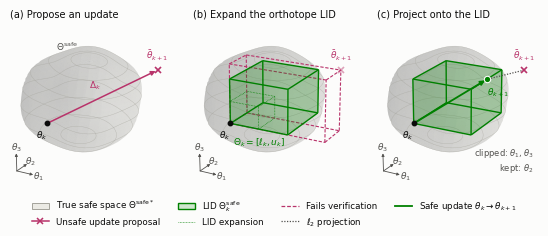

saved /vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/projects/safe_policy_optimisation/figures/pspo_safe_update_default_3d.pdf and .png


In [20]:
def build_figure(pspo_type: str = PSPO_TYPE):
    if pspo_type not in PSPO_TYPES:
        raise ValueError(f"pspo_type must be one of {PSPO_TYPES}, got {pspo_type!r}.")
    fig = plt.figure(figsize=(TEXT_WIDTH_IN, 2.25), layout="constrained", facecolor=SURFACE)
    for column, (draw, title) in enumerate(zip(PANELS[pspo_type], TITLES[pspo_type])):
        draw(fig.add_subplot(1, 3, column + 1, projection="3d"), title)
    fig.legend(handles=legend_handles(pspo_type), loc="outside lower center", ncol=4, frameon=False, fontsize=6.3)
    return fig


fig = build_figure(PSPO_TYPE)
save_paper_figure(fig, out_stem(PSPO_TYPE))
plt.show()
print(f"saved {out_stem(PSPO_TYPE).with_suffix('.pdf')} and .png")

## Using the figure

The figure is rendered at the ICLR text width, so include it at native size
(no `width=`, see `_paper_style.py`). The cell below prints a ready-to-paste
figure environment with a caption for the selected type.

In [8]:
CAPTIONS = {
    "default": (
        r"PSPO safe policy update (default, region-first). "
        r"(a)~PPO proposes $\bar\theta_{k+1}=\theta_k+\Delta_k$, which leaves $\Theta^{\mathrm{safe}}$. "
        r"(b)~The orthotope LID $\Theta_k=[\ell_k,u_k]$ grows from its vertex $\theta_k$ into the orthant "
        r"of $\Delta_k$ while the certificate holds; the box containing the proposal (dashed) fails it. "
        r"(c)~The $\ell_2$ projection onto a box clips only the coordinates that leave it "
        r"($<CLIPPED>$); $<KEPT>$ keeps its proposed value."
    ),
    "verify-first": (
        r"PSPO safe policy update (verify-first). "
        r"(a)~PPO proposes $\bar\theta_{k+1}=\theta_k+\Delta_k$, which leaves $\Theta^{\mathrm{safe}}$. "
        r"(b)~The proposal itself is checked exactly first: it would be accepted unchanged if its greedy "
        r"policy were shield-safe on every certified state, but it is not. "
        r"(c)~Only then is an orthotope LID grown from $\theta_k$ towards $\Delta_k$ (dotted: a growth "
        r"checkpoint) and the proposal projected onto it, clipping $<CLIPPED>$."
    ),
    "line-segment": (
        r"PSPO safe policy update (line segment). "
        r"(a)~PPO proposes $\bar\theta_{k+1}=\theta_k+\Delta_k$, which leaves $\Theta^{\mathrm{safe}}$. "
        r"(b)~The segment LID certifies the longest prefix $\theta_k+[0,\hat\alpha]\Delta_k$ of the step, "
        r"each of its $K$ sub-segments (ticks) separately; the rest of the step (dashed) fails. "
        r"(c)~The $\ell_2$ projection onto the segment is the shortened step "
        r"$\theta_{k+1}=\theta_k+\hat\alpha\Delta_k$."
    ),
}


def latex_figure(pspo_type: str = PSPO_TYPE) -> str:
    caption = CAPTIONS[pspo_type].replace("<CLIPPED>", CLIPPED_TEX).replace("<KEPT>", KEPT_TEX)
    stem = out_stem(pspo_type).name
    return "\n".join([
        r"\begin{figure}[t]",
        r"  \centering",
        rf"  \includegraphics{{figures/{stem}.pdf}}",
        rf"  \caption{{{caption}}}",
        rf"  \label{{fig:pspo-safe-update-{pspo_type}}}",
        r"\end{figure}",
    ])


print(latex_figure(PSPO_TYPE))

\begin{figure}[t]
  \centering
  \includegraphics{figures/pspo_safe_update_default_3d.pdf}
  \caption{PSPO safe policy update (default, region-first). (a)~PPO proposes $\bar\theta_{k+1}=\theta_k+\Delta_k$, which leaves $\Theta^{\mathrm{safe}}$. (b)~The orthotope LID $\Theta_k=[\ell_k,u_k]$ grows from its vertex $\theta_k$ into the orthant of $\Delta_k$ while the certificate holds; the box containing the proposal (dashed) fails it. (c)~The $\ell_2$ projection onto a box clips only the coordinates that leave it ($\theta_1,\theta_3$); $\theta_2$ keeps its proposed value.}
  \label{fig:pspo-safe-update-default}
\end{figure}
